<a href="https://colab.research.google.com/github/BramSimonnet/Deep-Learning-Homework/blob/main/problem4conditional-gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conditional GANs

Based on the excellent tutorial [here](https://github.com/Yangyangii/GAN-Tutorial/blob/master/MNIST/Conditional-GAN.ipynb).

## Libaries

As always, we load lots of libraries.

In [2]:
import torch
from torchvision import datasets
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import os
from matplotlib.pyplot import imsave
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Data

In [3]:
# A transform to convert the images to tensor and normalize their grayscale values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

data = datasets.FashionMNIST(
    root='../data/',
    train=True,
    transform=transform,
    download=True
)

batch_size = 64
data_loader = DataLoader(
    dataset=data,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.48MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.23MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.5MB/s]


## Architecture

We now instantiate the generator and discriminator architectures. The generator takes a random noise vector and a one hot encoded label as input and produces an image. The discriminator takes an image and a one hot encoded label as input and produces a single value between 0 and 1. The discriminator is trained to output 1 for real images and 0 for fake images. The generator is trained to fool the discriminator by outputting images that look real.

In [4]:
class Generator(nn.Module):
    def __init__(self, input_size=100, image_size=28*28):
        super(Generator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        y_ = self.network(x)
        y_ = y_.view(x.size(0), 1, 28, 28)
        return y_

In [5]:
class Discriminator(nn.Module):
    def __init__(self, input_size=28*28, num_output=1):
        super(Discriminator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, num_output),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        y_ = self.network(x)
        return y_

In [6]:
MODEL_NAME = 'GAN'
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

D = Discriminator().to(DEVICE)
G = Generator().to(DEVICE)

max_epoch = 10
step = 0
n_noise = 100

criterion = nn.BCELoss()
D_opt = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
G_opt = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

# We will denote real images as 1s and fake images as 0s
all_ones = torch.ones([batch_size, 1]).to(DEVICE)
all_zeros = torch.zeros([batch_size, 1]).to(DEVICE)

In [7]:
images, class_labels = next(iter(data_loader))
print(images.shape)
print(class_labels[:10])

torch.Size([64, 1, 28, 28])
tensor([0, 4, 9, 6, 7, 5, 1, 8, 4, 2])


In [9]:
import numpy as np

def get_sample_image(G, DEVICE, n_noise):
    G.eval()

    z = torch.randn(100, n_noise).to(DEVICE)  # 10x10 grid = 100 images
    fake_images = G(z)

    fake_images = fake_images.cpu().data.numpy()
    fake_images = (fake_images + 1) / 2  # [-1,1] → [0,1]

    img = np.zeros((28*10, 28*10))

    for i in range(10):
        for j in range(10):
            img[i*28:(i+1)*28, j*28:(j+1)*28] = fake_images[i*10 + j][0]

    return img

In [10]:
# a directory to save the generated images
if not os.path.exists('samples'):
    os.makedirs('samples')

for epoch in range(max_epoch):
    for idx, (images, _) in enumerate(data_loader):
        # Training Discriminator
        x = images.to(DEVICE)
        x_outputs = D(x)                            # discriminator sees only images
        D_x_loss = criterion(x_outputs, all_ones)  # real images -> 1

        z = torch.randn(batch_size, n_noise).to(DEVICE)
        fake_images = G(z)
        z_outputs = D(fake_images.detach())         # fake images -> 0
        D_z_loss = criterion(z_outputs, all_zeros)

        D_loss = D_x_loss + D_z_loss

        D.zero_grad()
        D_loss.backward()
        D_opt.step()

        # Training Generator
        z = torch.randn(batch_size, n_noise).to(DEVICE)
        fake_images = G(z)
        z_outputs = D(fake_images)
        G_loss = criterion(z_outputs, all_ones)     # generator wants D to think fakes are real

        G.zero_grad()
        G_loss.backward()
        G_opt.step()

        if step % 500 == 0:
            print('Epoch: {}/{}, Step: {}, D Loss: {}, G Loss: {}'.format(
                epoch, max_epoch, step, D_loss.item(), G_loss.item()
            ))

        if step % 1000 == 0:
            G.eval()
            img = get_sample_image(G, DEVICE, n_noise)
            imsave('samples/{}_step{}.jpg'.format(MODEL_NAME, str(step).zfill(3)), img, cmap='gray')
            G.train()

        step += 1

Epoch: 0/10, Step: 0, D Loss: 1.2405831813812256, G Loss: 0.7047445178031921
Epoch: 0/10, Step: 500, D Loss: 1.2316759824752808, G Loss: 1.401677131652832
Epoch: 1/10, Step: 1000, D Loss: 1.2685436010360718, G Loss: 1.0629572868347168
Epoch: 1/10, Step: 1500, D Loss: 1.3107261657714844, G Loss: 0.8321877717971802
Epoch: 2/10, Step: 2000, D Loss: 1.2674132585525513, G Loss: 1.2110557556152344
Epoch: 2/10, Step: 2500, D Loss: 1.3215765953063965, G Loss: 0.8786144852638245
Epoch: 3/10, Step: 3000, D Loss: 1.3317601680755615, G Loss: 0.9650416970252991
Epoch: 3/10, Step: 3500, D Loss: 1.3630772829055786, G Loss: 0.907618522644043
Epoch: 4/10, Step: 4000, D Loss: 1.2563285827636719, G Loss: 0.9330614805221558
Epoch: 4/10, Step: 4500, D Loss: 1.3051726818084717, G Loss: 0.8550440073013306
Epoch: 5/10, Step: 5000, D Loss: 1.297480821609497, G Loss: 0.8616881966590881
Epoch: 5/10, Step: 5500, D Loss: 1.3880256414413452, G Loss: 0.753415048122406
Epoch: 6/10, Step: 6000, D Loss: 1.3412930965423

In [14]:
import os
print(sorted(os.listdir('samples')))

['GAN_step000.jpg', 'GAN_step1000.jpg', 'GAN_step2000.jpg', 'GAN_step3000.jpg', 'GAN_step4000.jpg', 'GAN_step5000.jpg', 'GAN_step6000.jpg', 'GAN_step7000.jpg', 'GAN_step8000.jpg', 'GAN_step9000.jpg']


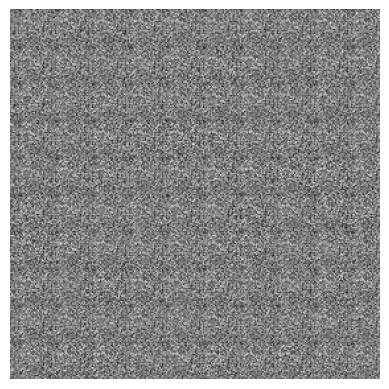

In [11]:
img = mpimg.imread('samples/GAN_step000.jpg')
imgplot = plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

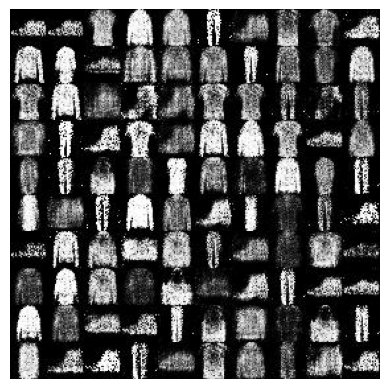

In [12]:
img = mpimg.imread('samples/GAN_step5000.jpg')
imgplot = plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

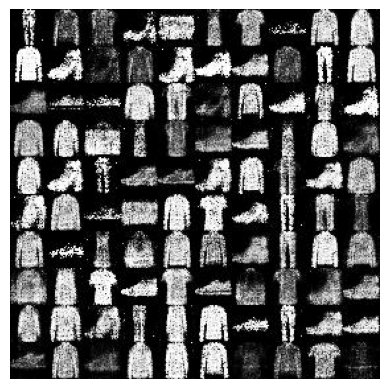

In [13]:


img = mpimg.imread('samples/GAN_step9000.jpg')
imgplot = plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

**(a) Train a standard GAN on FashionMNIST**

I adapted the provided Conditional GAN demo to train a standard (unconditional) GAN on FashionMNIST. The main changes were replacing the MNIST dataset with FashionMNIST and removing all label-conditioning from the generator, discriminator, and training loop. In this setting, the generator takes only a random noise vector as input, and the discriminator takes only an image as input and predicts whether it is real or fake.

The model was trained for 10 epochs using the same architecture and optimizer settings as in the demo. Sample images were saved during training to monitor progress.

At the beginning of training (step 0), the generated images appear as random noise with no recognizable structure. By step 5000, the generator begins to produce images with visible structure resembling clothing items such as shirts and shoes, although the images remain noisy and somewhat distorted. By step 9000, the generated samples become more recognizable and consistent, with clearer shapes and outlines. However, the images are still somewhat blurry and contain noticeable noise, and some samples appear repetitive.

Overall, the GAN successfully learns the general structure of the FashionMNIST dataset, but the generated images are not perfectly sharp or diverse, which is typical for basic GAN training.

In [16]:
# A transform to convert the images to tensor and normalize their grayscale values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

data = datasets.FashionMNIST(
    root='../data/',
    train=True,
    transform=transform,
    download=True
)

batch_size = 64
data_loader = DataLoader(dataset=data, batch_size=batch_size, shuffle=True, drop_last=True)

In [17]:
def to_onehot(x, num_classes=10):
    assert isinstance(x, int) or isinstance(x, (torch.LongTensor, torch.cuda.LongTensor))
    if isinstance(x, int):
        c = torch.zeros(1, num_classes).long()
        c[0][x] = 1
    else:
        x = x.cpu()
        c = torch.LongTensor(x.size(0), num_classes)
        c.zero_()
        c.scatter_(1, x, 1)
    return c

In [18]:
import numpy as np

def get_sample_image(G, DEVICE, n_noise):
    G.eval()

    z = torch.randn(100, n_noise).to(DEVICE)

    # Create labels 0,1,...,9 repeated 10 times
    labels = []
    for i in range(10):
        labels += [i] * 10
    labels = torch.LongTensor(labels).view(100, 1)
    labels = to_onehot(labels).to(DEVICE)

    fake_images = G(z, labels)
    fake_images = fake_images.cpu().data.numpy()
    fake_images = (fake_images + 1) / 2  # [-1,1] -> [0,1]

    img = np.zeros((28 * 10, 28 * 10))

    for i in range(10):
        for j in range(10):
            img[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = fake_images[i * 10 + j][0]

    return img

In [19]:
class Generator(nn.Module):
    def __init__(self, input_size=100, num_classes=10, image_size=28*28):
        super(Generator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size + num_classes, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size),
            nn.Tanh()
        )

    def forward(self, x, c):
        x = x.view(x.size(0), -1)
        c = c.view(c.size(0), -1).float()
        v = torch.cat((x, c), 1)
        y_ = self.network(v)
        y_ = y_.view(x.size(0), 1, 28, 28)
        return y_

In [20]:
class Discriminator(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10, num_output=1):
        super(Discriminator, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, num_output),
            nn.Sigmoid(),
        )

    def forward(self, x, c):
        x = x.view(x.size(0), -1)
        c = c.view(c.size(0), -1).float()
        v = torch.cat((x, c), 1)
        y_ = self.network(v)
        return y_

In [21]:
MODEL_NAME = 'ConditionalGAN'
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

D = Discriminator().to(DEVICE)
G = Generator().to(DEVICE)

max_epoch = 10
step = 0
n_noise = 100

criterion = nn.BCELoss()
D_opt = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
G_opt = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

all_ones = torch.ones([batch_size, 1]).to(DEVICE)
all_zeros = torch.zeros([batch_size, 1]).to(DEVICE)

In [22]:
images, class_labels = next(iter(data_loader))
class_labels_encoded = class_labels.view(batch_size, 1)
class_labels_encoded = to_onehot(class_labels_encoded).to(DEVICE)

print(class_labels[:10])
print(class_labels_encoded[:10])

tensor([2, 8, 3, 7, 0, 1, 0, 7, 4, 0])
tensor([[0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]], device='cuda:0')


In [23]:
# a directory to save the generated images
if not os.path.exists('samples'):
    os.makedirs('samples')

for epoch in range(max_epoch):
    for idx, (images, class_labels) in enumerate(data_loader):
        # Training Discriminator
        x = images.to(DEVICE)

        class_labels = class_labels.view(batch_size, 1)
        class_labels = to_onehot(class_labels).to(DEVICE)

        x_outputs = D(x, class_labels)
        D_x_loss = criterion(x_outputs, all_ones)

        z = torch.randn(batch_size, n_noise).to(DEVICE)
        fake_images = G(z, class_labels)
        z_outputs = D(fake_images.detach(), class_labels)
        D_z_loss = criterion(z_outputs, all_zeros)

        D_loss = D_x_loss + D_z_loss

        D.zero_grad()
        D_loss.backward()
        D_opt.step()

        # Training Generator
        z = torch.randn(batch_size, n_noise).to(DEVICE)
        fake_images = G(z, class_labels)
        z_outputs = D(fake_images, class_labels)
        G_loss = criterion(z_outputs, all_ones)

        G.zero_grad()
        G_loss.backward()
        G_opt.step()

        if step % 500 == 0:
            print('Epoch: {}/{}, Step: {}, D Loss: {}, G Loss: {}'.format(
                epoch, max_epoch, step, D_loss.item(), G_loss.item()
            ))

        if step % 1000 == 0:
            G.eval()
            img = get_sample_image(G, DEVICE, n_noise)
            imsave('samples/{}_step{}.jpg'.format(MODEL_NAME, str(step).zfill(3)), img, cmap='gray')
            G.train()

        step += 1

Epoch: 0/10, Step: 0, D Loss: 1.3585469722747803, G Loss: 0.6991990208625793
Epoch: 0/10, Step: 500, D Loss: 0.9685158729553223, G Loss: 1.5441423654556274
Epoch: 1/10, Step: 1000, D Loss: 1.1750004291534424, G Loss: 1.3550527095794678
Epoch: 1/10, Step: 1500, D Loss: 1.278577208518982, G Loss: 0.9403702020645142
Epoch: 2/10, Step: 2000, D Loss: 1.2838168144226074, G Loss: 0.8182582855224609
Epoch: 2/10, Step: 2500, D Loss: 1.317031741142273, G Loss: 1.3493316173553467
Epoch: 3/10, Step: 3000, D Loss: 1.3108184337615967, G Loss: 0.848114550113678
Epoch: 3/10, Step: 3500, D Loss: 1.3472914695739746, G Loss: 1.2410430908203125
Epoch: 4/10, Step: 4000, D Loss: 1.2593166828155518, G Loss: 0.8098738193511963
Epoch: 4/10, Step: 4500, D Loss: 1.279447317123413, G Loss: 0.8511566519737244
Epoch: 5/10, Step: 5000, D Loss: 1.4841670989990234, G Loss: 0.6637794971466064
Epoch: 5/10, Step: 5500, D Loss: 1.3399840593338013, G Loss: 0.783899188041687
Epoch: 6/10, Step: 6000, D Loss: 1.37089753150939

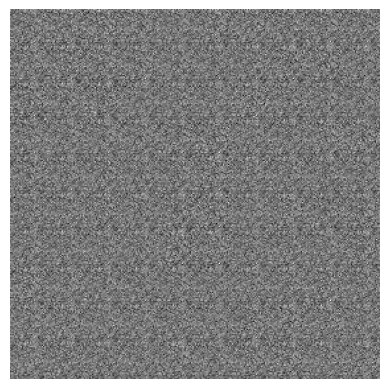

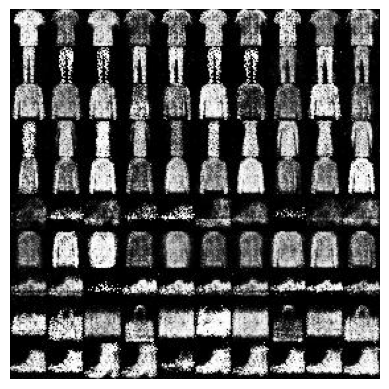

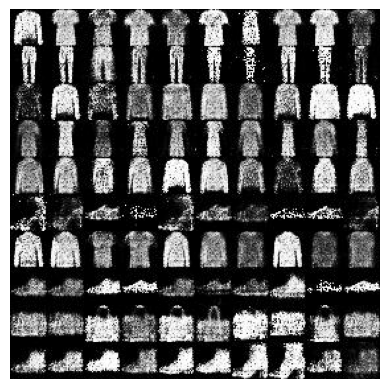

In [24]:
img = mpimg.imread('samples/ConditionalGAN_step000.jpg')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

img = mpimg.imread('samples/ConditionalGAN_step5000.jpg')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

img = mpimg.imread('samples/ConditionalGAN_step9000.jpg')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [26]:
def generate_class_samples(G, DEVICE, n_noise, class_idx, num_samples=10):
    G.eval()

    z = torch.randn(num_samples, n_noise).to(DEVICE)

    labels = torch.LongTensor([[class_idx] for _ in range(num_samples)])
    labels = to_onehot(labels).to(DEVICE)

    fake_images = G(z, labels)
    fake_images = fake_images.cpu().data.numpy()
    fake_images = (fake_images + 1) / 2

    fig, axes = plt.subplots(1, num_samples, figsize=(15, 2))
    for i in range(num_samples):
        axes[i].imshow(fake_images[i][0], cmap='gray')
        axes[i].axis('off')

    plt.suptitle(f'Class {class_idx}')
    plt.show()

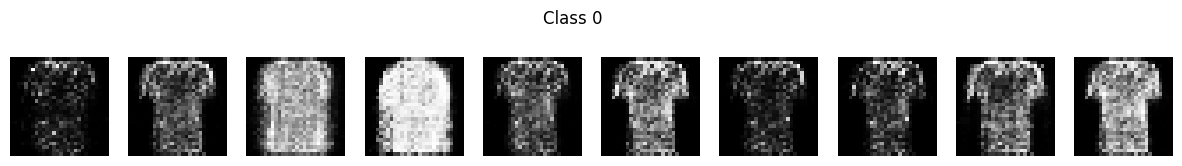

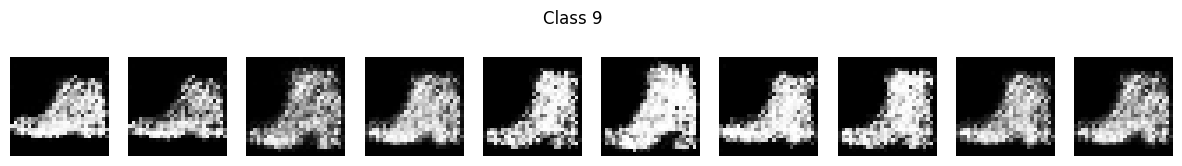

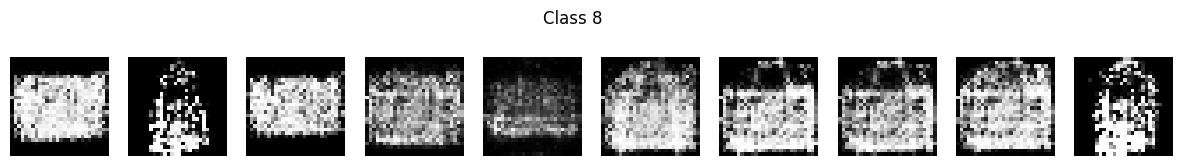

In [27]:
generate_class_samples(G, DEVICE, n_noise, 0)
generate_class_samples(G, DEVICE, n_noise, 9)
generate_class_samples(G, DEVICE, n_noise, 8)

# (c) Measures of GAN quality

Several metrics are commonly used to evaluate the quality of GAN-generated images.

One widely used metric is the Inception Score (IS), which measures both the quality and diversity of generated samples. It evaluates how confidently a pretrained classifier can assign labels to generated images, while also encouraging diversity across different classes. Higher scores indicate better quality and more diverse samples.

Another important metric is the Fréchet Inception Distance (FID), which compares the distribution of generated images to the distribution of real images in a feature space extracted by a pretrained network. Lower FID scores indicate that the generated images are closer to real images in terms of both quality and diversity.

Other metrics include Precision and Recall for GANs, which separately measure the quality (precision) and diversity (recall) of generated samples.

In this assignment, these metrics were not explicitly computed. Instead, model performance was evaluated qualitatively by visually inspecting generated samples. The results show that the models are able to capture the general structure of the FashionMNIST dataset, although the images remain somewhat noisy and lack sharpness.

# (d) Compare GAN vs. Conditional GAN

**Sample quality and diversity**

The Conditional GAN produces more structured and organized samples compared to the standard GAN. In the standard GAN, generated images contain a mixture of different clothing types and lack clear grouping, while the Conditional GAN generates images that are grouped by class. The Conditional GAN also produces slightly more consistent shapes within each class, although both models still generate somewhat noisy and blurry images.

**Class-specific generation**

The Conditional GAN is able to generate specific classes reliably. When fixing the input label, the generated samples consistently correspond to the desired category (e.g., T-shirts, boots, or bags). For example, samples generated with label 9 clearly resemble ankle boots, while label 0 produces shirt-like shapes. This demonstrates that the model successfully learns to condition on class labels. In contrast, the standard GAN cannot control which class is generated and produces a mixture of categories.

**Training stability**

Both models exhibit similar training behavior in terms of loss values and convergence. However, the Conditional GAN appears slightly more stable in terms of output structure, as it produces more organized and consistent samples during training. Conditioning provides additional information to the model, which can help guide learning and improve the quality of generated outputs.

Overall, the Conditional GAN improves upon the standard GAN by enabling class control and producing more structured samples, although both models still suffer from noise and limited sharpness.